## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#importando a base de dados
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/aulas/semana_04/bases/base_rh.xlsx"
)
df = pd.read_excel(URL)
#analise inicial da base de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID_Funcionario  1000 non-null   int64  
 1   Nome            1000 non-null   str    
 2   Departamento    1000 non-null   str    
 3   Cargo           1000 non-null   str    
 4   Salario         1000 non-null   float64
 5   Data_Admissao   1000 non-null   str    
 6   Genero          1000 non-null   str    
 7   Idade           1000 non-null   int64  
 8   Estado_Civil    1000 non-null   str    
 9   Status          1000 non-null   str    
dtypes: float64(1), int64(2), str(7)
memory usage: 78.3 KB


In [3]:
#conversar coluna de data para o formato datetime
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)
#Criando ano de admissão
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID_Funcionario  1000 non-null   int64         
 1   Nome            1000 non-null   str           
 2   Departamento    1000 non-null   str           
 3   Cargo           1000 non-null   str           
 4   Salario         1000 non-null   float64       
 5   Data_Admissao   1000 non-null   datetime64[us]
 6   Genero          1000 non-null   str           
 7   Idade           1000 non-null   int64         
 8   Estado_Civil    1000 non-null   str           
 9   Status          1000 non-null   str           
 10  Ano_Admissao    1000 non-null   int32         
dtypes: datetime64[us](1), float64(1), int32(1), int64(2), str(6)
memory usage: 82.2 KB


2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.

In [5]:
qtdFuncCargo = (
    df.groupby("Departamento")["Cargo"]
.value_counts()
.reset_index(name="Qtd_Funcionarios")
.sort_values(["Departamento", "Qtd_Funcionarios"], ascending=[True, False])
)
print(qtdFuncCargo)

   Departamento        Cargo  Qtd_Funcionarios
0    Financeiro      Gerente                44
1    Financeiro     Analista                40
2    Financeiro      Técnico                38
3    Financeiro  Coordenador                37
4    Financeiro   Assistente                30
5     Logística  Coordenador                38
6     Logística   Assistente                38
7     Logística      Gerente                33
8     Logística     Analista                29
9     Logística      Técnico                18
10     Produção      Gerente                43
11     Produção   Assistente                41
12     Produção  Coordenador                40
13     Produção      Técnico                36
14     Produção     Analista                22
15           RH  Coordenador                44
16           RH   Assistente                35
17           RH     Analista                32
18           RH      Gerente                30
19           RH      Técnico                25
20           

3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.


In [6]:
qtd_admissao = df.query("2020 <= Ano_Admissao <= 2024")["Ano_Admissao"].value_counts().sort_index().reset_index(name="Admissoes")
print(qtd_admissao)
print(f"Total de admissões entre 2020 e 2024: {qtd_admissao['Admissoes'].sum()}")
print(df.head())

   Ano_Admissao  Admissoes
0          2020         94
1          2021         94
2          2022        108
3          2023        106
4          2024        113
Total de admissões entre 2020 e 2024: 515
   ID_Funcionario                 Nome Departamento        Cargo   Salario  \
0               1          Julia Nunes    Logística  Coordenador   9088.34   
1               2   Sr. Gustavo Duarte           TI      Gerente   8155.98   
2               3  Srta. Mariana Cunha           RH  Coordenador  14027.93   
3               4   Ana Sophia da Cruz     Produção      Técnico   6647.97   
4               5    Dr. Nicolas Pinto     Produção      Gerente   8730.19   

  Data_Admissao Genero  Idade Estado_Civil   Status  Ano_Admissao  
0    2024-08-13      F     43     Solteiro  Inativo          2024  
1    2017-04-29      F     59     Solteiro  Inativo          2017  
2    2024-12-11      F     27   Divorciado    Ativo          2024  
3    2019-06-16      M     50       Casado  Inativo    

4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.


In [7]:
metas_headcount = pd.DataFrame({
    "Departamento": ["Financeiro", "Logística", "Manutenção",
                     "Produção", "RH", "TI", "Vendas"],
    "Meta_Headcount": [135, 130, 125, 185, 167, 136, 190]
})

real_headcount = (
    df.groupby("Departamento")
    .size()
    .reset_index(name="Total_Real")
    .sort_values("Departamento")
)

comparacao_hc = pd.merge(
    real_headcount,
    metas_headcount,
    on="Departamento",
    how="left"
)
print(comparacao_hc)
# Identifica se a meta foi atingida
comparacao_hc["Diferenca"]    = comparacao_hc["Total_Real"] - comparacao_hc["Meta_Headcount"]
comparacao_hc["Atingiu_Meta"] = comparacao_hc["Diferenca"].apply(
    lambda x: "✅ Sim" if x >= 0 else "❌ Não"
)

print("\nComparação real vs meta:")
print(comparacao_hc.to_string(index=False))

  Departamento  Total_Real  Meta_Headcount
0   Financeiro         189             135
1    Logística         156             130
2     Produção         182             185
3           RH         166             167
4           TI         147             136
5       Vendas         160             190

Comparação real vs meta:
Departamento  Total_Real  Meta_Headcount  Diferenca Atingiu_Meta
  Financeiro         189             135         54        ✅ Sim
   Logística         156             130         26        ✅ Sim
    Produção         182             185         -3        ❌ Não
          RH         166             167         -1        ❌ Não
          TI         147             136         11        ✅ Sim
      Vendas         160             190        -30        ❌ Não


5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.


In [8]:
pivot_genero = pd.pivot_table(
    df,                         #Primeiro parametro é o DataFrame
    values   = "Salario",       #Parametro values é a coluna que queremos analisar
    index    = "Departamento",  #Parametro index é a coluna que queremos usar como indice
    columns  = "Genero",        #Parametro columns é a coluna que queremos usar como coluna
    aggfunc  = "mean",          #Parametro aggfunc é a função de agregação que queremos usar, nesse caso a média 
    fill_value = 0              #Parametro fill_value é o valor que queremos usar para preencher os valores faltantes, nesse caso 0
).round(2)
pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2)
pivot_genero = pivot_genero.sort_values("Diferenca_F_M", ascending=False)
print(pivot_genero)
print("\nDepartamentos com maior diferença salarial entre gêneros (F - M):")
print(f"A maior diferença de F para M está no {pivot_genero.index[0]} com uma diferença de R$ {pivot_genero['Diferenca_F_M'].iloc[0]:.2f}")
print(f"A maior diferença de M para F está no {pivot_genero.index[-1]} com uma diferença de R$ {pivot_genero['Diferenca_F_M'].iloc[-1]:.2f}")
print(f"Em média, as mulheres ganham R$ {pivot_genero['Diferenca_F_M'].mean():.2f} a mais que os homens")


Genero              F        M  Diferenca_F_M
Departamento                                 
Vendas        8926.64  7751.59        1175.05
RH            9009.20  8546.06         463.14
Financeiro    8467.26  8208.56         258.70
TI            8107.01  8177.38         -70.37
Logística     8843.49  8944.41        -100.92
Produção      8797.64  9118.66        -321.02

Departamentos com maior diferença salarial entre gêneros (F - M):
A maior diferença de F para M está no Vendas com uma diferença de R$ 1175.05
A maior diferença de M para F está no Produção com uma diferença de R$ -321.02
Em média, as mulheres ganham R$ 234.10 a mais que os homens


6. Plote admissões por ano com `plt.plot(..., marker="o")`.


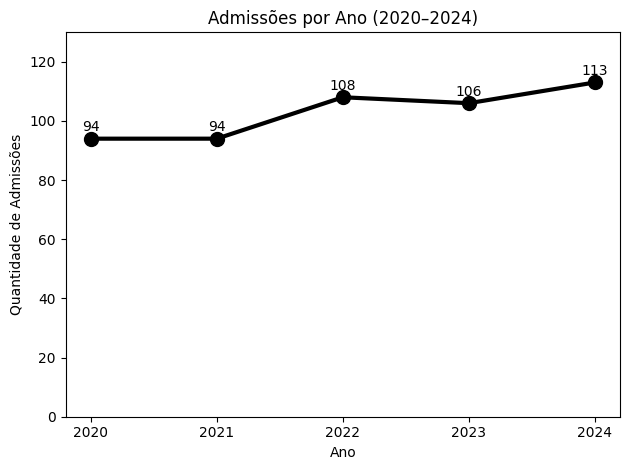

In [13]:
plt.plot(
    qtd_admissao["Ano_Admissao"],
    qtd_admissao["Admissoes"],
    marker="o",
    color="black",
    linewidth=3,
    markersize=10
)
for _, row in qtd_admissao.iterrows():
    plt.text(row["Ano_Admissao"], row["Admissoes"] + 1.5,
             str(int(row["Admissoes"])),
             ha="center", va="bottom", fontsize=10)

plt.title("Admissões por Ano (2020–2024)")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Admissões")
plt.xticks(qtd_admissao["Ano_Admissao"].astype(int))
plt.ylim(0, qtd_admissao["Admissoes"].max() * 1.15)
plt.tight_layout()
plt.show()

7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.


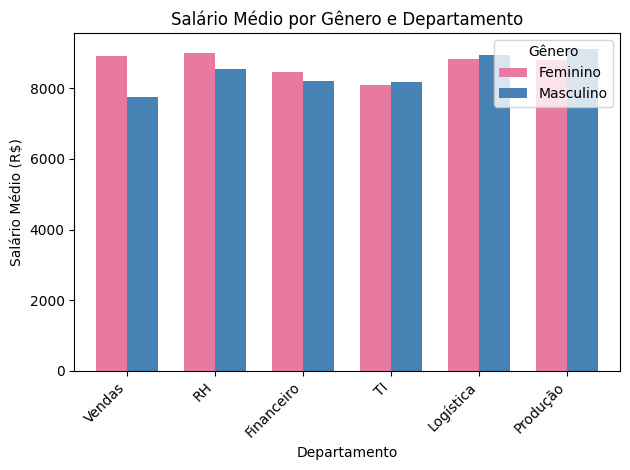

In [ ]:
pivot_genero[["F", "M"]].plot(
    kind="bar",
    color=["#e879a0", "steelblue"],
    width=0.7
)

plt.title("Salário Médio por Gênero e Departamento")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gênero", labels=["Feminino", "Masculino"])
plt.tight_layout()
plt.show()

8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.